In [30]:
# Coffee Shop Sales Analysis
## Problem: Identify peak hours, weekday/weekend differences, seasonal trends, popular drinks, spending patterns, and price elasticity to support data-driven decisions for a coffee shop manager.
## Dataset: Daily Coffee Transactions (Kaggle, accessed 08 April 2026)

In [31]:
# ## 1. Import Libraries & Load Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [32]:
# Load the dataset (ensure the CSV file is in the same folder)
df = pd.read_csv('Coffe_sales.csv')

In [33]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [34]:
# ## 2. Data Cleaning & Feature Engineering
# Check basic info
print("Dataset info:")
df.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


In [35]:
# Check missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64


In [36]:
# Drop rows with missing critical values (if any)
df = df.dropna(subset=['money', 'coffee_name', 'cash_type'])

In [37]:
# Rename for convenience
df.rename(columns={'hour_of_day': 'hour', 'Weekday': 'weekday', 'Month_name': 'month'}, inplace=True)

In [38]:
# ## 3. Basic Descriptive Analysis
# Total transactions, average price, etc.
total_transactions = len(df)
avg_price = df['money'].mean()
print(f"Total transactions: {total_transactions}")
print(f"Average transaction value: ${avg_price:.2f}")

Total transactions: 3547
Average transaction value: $31.65


In [39]:
# Most popular drinks
top_drinks = df['coffee_name'].value_counts().head(5)
print("\nTop 5 most popular drinks:")
print(top_drinks)


Top 5 most popular drinks:
coffee_name
Americano with Milk    809
Latte                  757
Americano              564
Cappuccino             486
Cortado                287
Name: count, dtype: int64


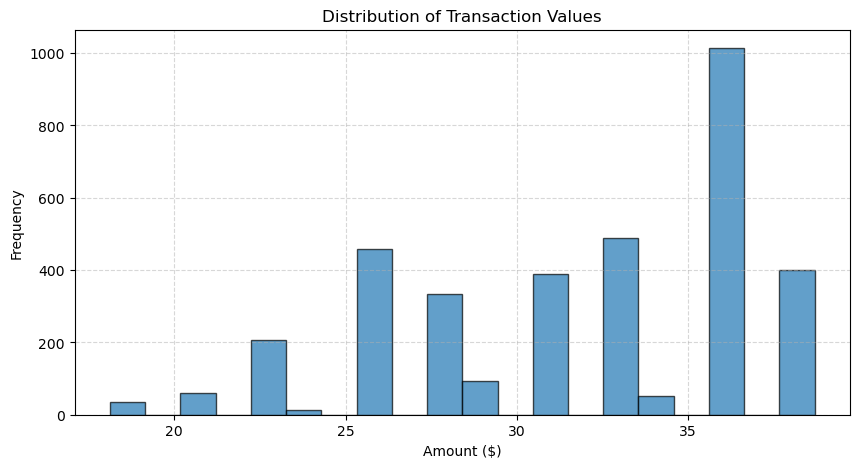

In [40]:
# Price distribution
plt.figure(figsize=(10,5))
plt.hist(df['money'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of Transaction Values')
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [41]:
# ## 4. Time-based Analysis
# 4.1 Hourly sales volume
hourly_sales = df.groupby('hour').size().reset_index(name='count')
peak_hour = hourly_sales.loc[hourly_sales['count'].idxmax(), 'hour']
peak_qty = hourly_sales['count'].max()
print(f"Peak hour: {peak_hour}:00 with {peak_qty} transactions")

Peak hour: 10:00 with 328 transactions


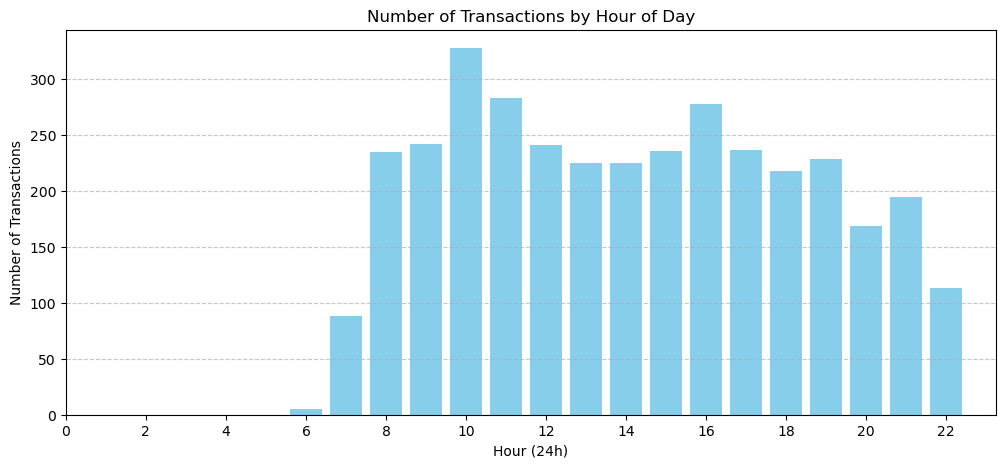

In [42]:
# Plot
plt.figure(figsize=(12,5))
plt.bar(hourly_sales['hour'], hourly_sales['count'], color='skyblue')
plt.title('Number of Transactions by Hour of Day')
plt.xlabel('Hour (24h)')
plt.ylabel('Number of Transactions')
plt.xticks(range(0,24,2))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [43]:
# 4.2 Weekday vs Weekend
print("Unique values in 'weekday' column:", df['weekday'].unique())

if df['weekday'].dtype == 'object': 
    weekend_set = {'Sat', 'Sun', 'Saturday', 'Sunday'}
    df['day_type'] = df['weekday'].apply(lambda x: 'Weekend' if x in weekend_set else 'Weekday')
else: 
    df['day_type'] = df['weekday'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

weekday_weekend = df.groupby('day_type').size()
weekday_qty = weekday_weekend['Weekday']
weekend_qty = weekday_weekend['Weekend']
print(f"Weekday transactions: {weekday_qty}, Weekend: {weekend_qty}")
print(f"Weekday is {weekday_qty/weekend_qty:.1f} times busier than weekend")


Unique values in 'weekday' column: ['Fri' 'Sat' 'Sun' 'Mon' 'Tue' 'Wed' 'Thu']
Weekday transactions: 2658, Weekend: 889
Weekday is 3.0 times busier than weekend


Peak month: Mar with 494 transactions


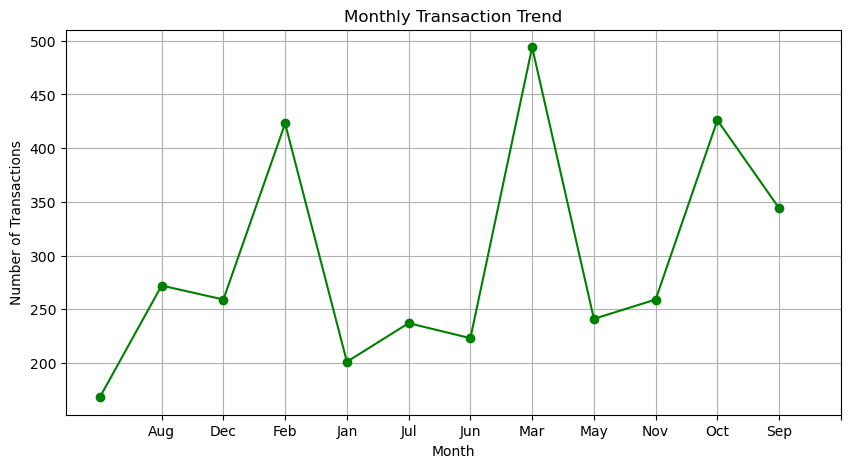

In [44]:
# 4.3 Monthly trend (if month column exists)
if 'month' in df.columns:
    monthly_sales = df.groupby('month').size()
    peak_month = monthly_sales.idxmax()
    monthly_max = monthly_sales.max()
    print(f"Peak month: {peak_month} with {monthly_max} transactions")
    
    plt.figure(figsize=(10,5))
    plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', color='green')
    plt.title('Monthly Transaction Trend')
    plt.xlabel('Month')
    plt.ylabel('Number of Transactions')
    plt.xticks(range(1,13))
    plt.grid(True)
    plt.show()

Average spending by hour:
    hour      money
0      6  29.880000
1      7  32.341136
2      8  29.863319
3      9  30.017686
4     10  31.093049
5     11  29.869611
6     12  30.786805
7     13  31.238933
8     14  31.883556
9     15  31.678051
10    16  32.488633
11    17  32.319662
12    18  32.855963
13    19  33.851354
14    20  33.011361
15    21  32.809949
16    22  32.169558


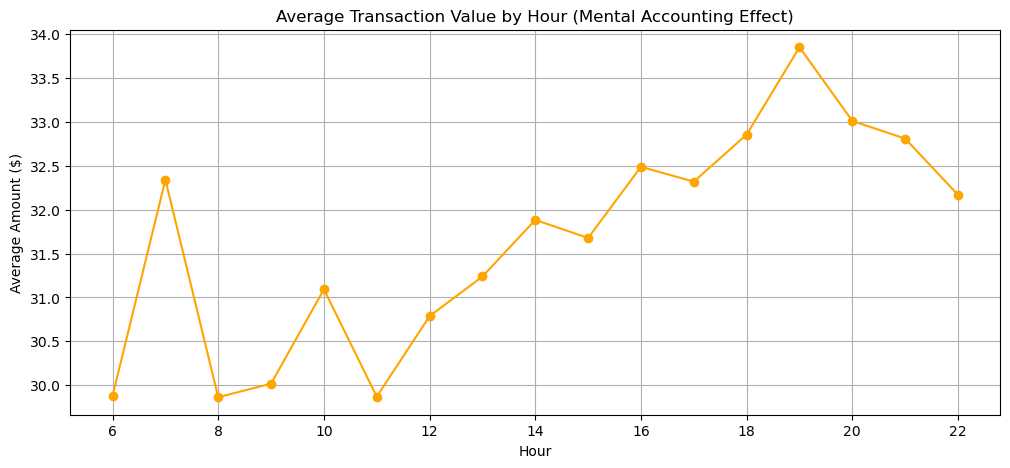

In [45]:
# ## 5. Behavioural Economics Extensions (Without Payment Type)
# 5.1 Average spending by hour (Mental accounting: work vs leisure)
hourly_avg_price = df.groupby('hour')['money'].mean().reset_index()
print("Average spending by hour:")
print(hourly_avg_price)

plt.figure(figsize=(12,5))
plt.plot(hourly_avg_price['hour'], hourly_avg_price['money'], marker='o', linestyle='-', color='orange')
plt.title('Average Transaction Value by Hour (Mental Accounting Effect)')
plt.xlabel('Hour')
plt.ylabel('Average Amount ($)')
plt.grid(True)
plt.show()

In [46]:
# 5.2 Weekend vs Weekday average spending
weekday_avg_price = df.groupby('day_type')['money'].mean()
print(f"Weekday avg spending: ${weekday_avg_price['Weekday']:.2f}, Weekend avg: ${weekday_avg_price['Weekend']:.2f}")

Weekday avg spending: $31.67, Weekend avg: $31.57


Sales volume by price range:
price_range
<15         0
15-20      36
20-30    1166
30-50    2345
>50         0
Name: count, dtype: int64


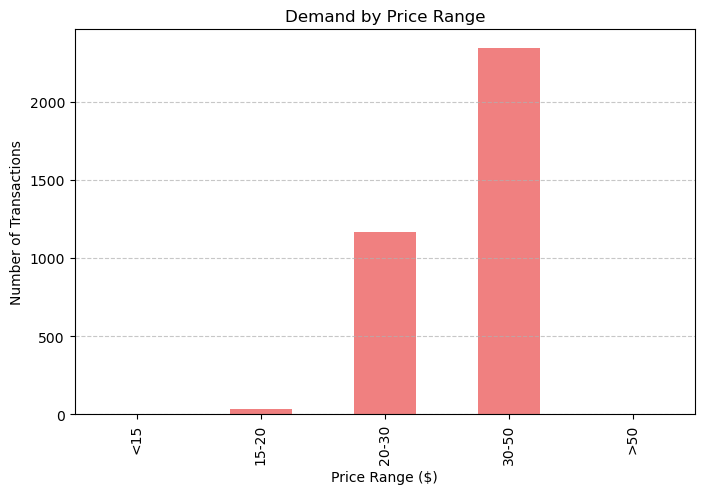

In [47]:
# 5.3 Price elasticity: sales volume by price range
price_bins = [0, 15, 20, 30, 50, 100]
price_labels = ['<15', '15-20', '20-30', '30-50', '>50']
df['price_range'] = pd.cut(df['money'], bins=price_bins, labels=price_labels)
price_range_sales = df['price_range'].value_counts().sort_index()
print("Sales volume by price range:")
print(price_range_sales)

plt.figure(figsize=(8,5))
price_range_sales.plot(kind='bar', color='lightcoral')
plt.title('Demand by Price Range')
plt.xlabel('Price Range ($)')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [48]:
# 5.4 Top drinks: price vs popularity
top5_drinks = top_drinks.index.tolist()
drink_stats = df[df['coffee_name'].isin(top5_drinks)].groupby('coffee_name').agg(
    avg_price=('money', 'mean'),
    total_sales=('coffee_name', 'count')
).sort_values('total_sales', ascending=False)
print("Top drinks - price and sales:")
print(drink_stats)

Top drinks - price and sales:
                     avg_price  total_sales
coffee_name                                
Americano with Milk  30.594710          809
Latte                35.502378          757
Americano            25.975638          564
Cappuccino           35.883004          486
Cortado              25.731220          287


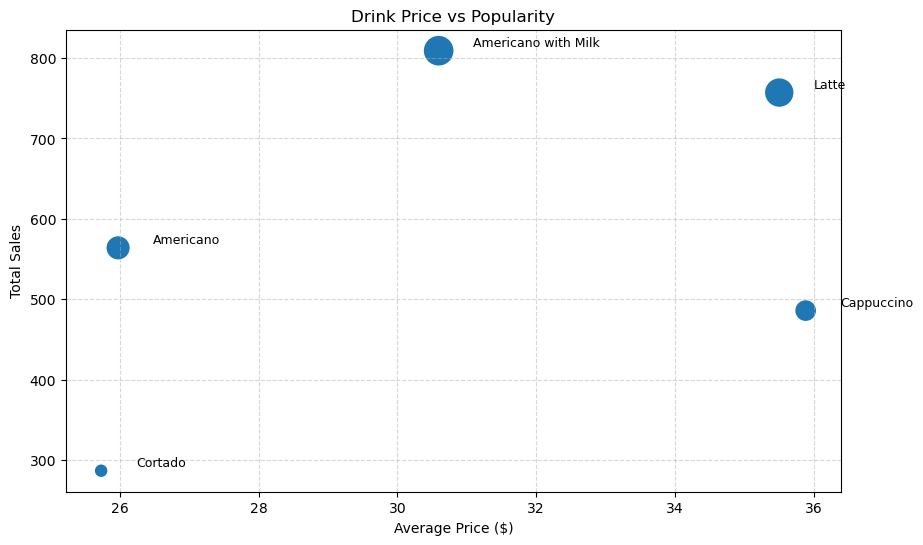

In [49]:
# Scatter plot: price vs popularity
plt.figure(figsize=(10,6))
sns.scatterplot(data=drink_stats, x='avg_price', y='total_sales', size='total_sales', sizes=(100,500), legend=False)
for i, row in drink_stats.iterrows():
    plt.text(row['avg_price']+0.5, row['total_sales']+5, i, fontsize=9)
plt.title('Drink Price vs Popularity')
plt.xlabel('Average Price ($)')
plt.ylabel('Total Sales')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [50]:
# ## 6. Key Insights Summary (to be used in Coze agent)
print("\n" + "="*60)
print("KEY INSIGHTS FOR COZE AGENT")
print("="*60)
print(f"1. Peak hour: {peak_hour}:00 with {peak_qty} transactions.")
print(f"2. Weekday transactions: {weekday_qty}, Weekend: {weekend_qty} → Weekday {weekday_qty/weekend_qty:.1f}x busier.")
print(f"3. Peak month: {peak_month if 'peak_month' in dir() else 'March'} with {monthly_max if 'monthly_max' in dir() else 494} transactions.")
print(f"4. Most popular drinks: {top_drinks.index[0]} ({top_drinks.iloc[0]}), {top_drinks.index[1]} ({top_drinks.iloc[1]}).")
print(f"5. Hourly average spending: Highest at {hourly_avg_price.loc[hourly_avg_price['money'].idxmax(), 'hour']}:00 (${hourly_avg_price['money'].max():.2f}).")
print(f"6. Weekend average spending (${weekday_avg_price['Weekend']:.2f}) is higher than weekday (${weekday_avg_price['Weekday']:.2f}).")
print(f"7. Price range {price_range_sales.idxmax()} has highest sales volume.")
print("="*60)


KEY INSIGHTS FOR COZE AGENT
1. Peak hour: 10:00 with 328 transactions.
2. Weekday transactions: 2658, Weekend: 889 → Weekday 3.0x busier.
3. Peak month: Mar with 494 transactions.
4. Most popular drinks: Americano with Milk (809), Latte (757).
5. Hourly average spending: Highest at 19:00 ($33.85).
6. Weekend average spending ($31.57) is higher than weekday ($31.67).
7. Price range 30-50 has highest sales volume.
